# LSTM model with full input (no PCA)

**Directly predict *near-term* volatility from the full set of features.**

Author: Pete King

Here again we train a LSTM model to predict near-term volatility for a single ETF, but this time we use all features available in the dataset.

The purpose of this notebook is to explore how well the model adapts to a large amount of additional features, compared to our original test using very limited input (returns and historical volatility), and later to an expanded but still limited set of extracted features the we developed using PCA.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

from helpers import data_prep as dp
from helpers import models

IMAGE_DIR = Path.cwd() / 'images'
DATA_DIR = Path.cwd().parent / 'data' / 'train-val-test'
TRAIN_DATA_FILE = DATA_DIR / 'train_BASE_DATA.csv'
VAL_DATA_FILE = DATA_DIR / 'val_BASE_DATA.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 10  # No. observations in each input sequence to LSTM
BATCH_SIZE = 21  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols, _ = dp.get_X_y_cols(train_df, returns=False)
label_col = [TICKER + '_vol_target']
train_df[data_cols + label_col].head(SEQUENCE_LENGTH + 1)

,BIL_vol-h,BND_vol-h,GLD_vol-h,HYG_vol-h,IEF_vol-h,IWM_vol-h,LQD_vol-h,QQQ_vol-h,SPY_vol-h,TIP_vol-h,...,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff,SPY_vol_target
date,,,,,,,,,,,,,,,,,,,,,
2015-10-15,0.000000,0.002023,0.011018,0.001742,0.003279,0.013053,0.002561,0.008202,0.007701,0.002297,...,0.000709,0.023973,0.008357,0.015144,0.015087,0.008546,0.007600,0.011329,0.042,0.007586
2015-10-16,0.000000,0.002028,0.009054,0.002690,0.003291,0.013036,0.002558,0.008165,0.007959,0.002276,...,0.000740,0.025340,0.007221,0.008305,0.015647,0.008503,0.007862,0.011671,0.000,0.008211
2015-10-19,0.000000,0.001879,0.009074,0.002824,0.002939,0.013047,0.001812,0.008487,0.007951,0.002262,...,0.000749,0.016360,0.007512,0.010626,0.014675,0.008102,0.007842,0.010355,0.005,0.008211
2015-10-20,0.000098,0.001990,0.009245,0.002654,0.003289,0.011520,0.001968,0.008304,0.007453,0.002309,...,0.000778,0.016158,0.007714,0.009271,0.014504,0.007859,0.007247,0.010169,0.043,0.008897
2015-10-21,0.000139,0.001399,0.006450,0.002676,0.002689,0.012664,0.002384,0.008714,0.007660,0.001759,...,0.000482,0.016521,0.006746,0.007679,0.019282,0.005936,0.007408,0.009758,-0.041,0.008794
2015-10-22,0.000139,0.001334,0.006119,0.002464,0.002259,0.007997,0.002559,0.010206,0.008269,0.002173,...,0.000434,0.016427,0.006081,0.008524,0.015694,0.003880,0.008111,0.004352,-0.005,0.008038
2015-10-23,0.000139,0.001749,0.005289,0.002079,0.003372,0.009101,0.003035,0.015906,0.009382,0.001920,...,0.000529,0.016103,0.005996,0.010138,0.024396,0.005458,0.009258,0.006505,0.058,0.007682
2015-10-26,0.000170,0.001817,0.004954,0.001758,0.003561,0.009564,0.003139,0.015702,0.009444,0.001765,...,0.000505,0.011200,0.004764,0.007755,0.052128,0.005485,0.009296,0.006540,-0.025,0.007668
2015-10-27,0.000139,0.001676,0.004191,0.002249,0.003402,0.010739,0.003026,0.015558,0.009466,0.001962,...,0.000459,0.013357,0.004416,0.007751,0.052162,0.006551,0.009345,0.006342,-0.030,0.007657


In [3]:
val_df[data_cols + label_col]

,BIL_vol-h,BND_vol-h,GLD_vol-h,HYG_vol-h,IEF_vol-h,IWM_vol-h,LQD_vol-h,QQQ_vol-h,SPY_vol-h,TIP_vol-h,...,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff,SPY_vol_target
date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,0.000254,0.004925,0.006532,0.009604,0.005978,0.013817,0.007952,0.014183,0.010149,0.003497,...,0.000963,0.022127,0.007543,0.006287,0.076669,0.007242,0.009848,0.010195,-0.086,0.011025
2023-01-04,0.000259,0.004318,0.006791,0.009841,0.005767,0.014577,0.006326,0.012850,0.010569,0.002845,...,0.000869,0.032962,0.006712,0.006061,0.077316,0.007436,0.010246,0.017094,-0.084,0.011143
2023-01-05,0.000259,0.004301,0.008570,0.007809,0.005703,0.013663,0.006178,0.013401,0.010334,0.002803,...,0.001059,0.033193,0.007824,0.011092,0.077269,0.007927,0.010157,0.017635,0.011,0.010940
2023-01-06,0.000176,0.006304,0.011658,0.008238,0.007773,0.012654,0.008994,0.014555,0.012081,0.004593,...,0.001979,0.033046,0.010177,0.015203,0.075911,0.008764,0.012052,0.017319,-0.151,0.010161
2023-01-09,0.000195,0.006144,0.011513,0.008384,0.007631,0.012615,0.008717,0.014836,0.012026,0.004513,...,0.001950,0.031764,0.010378,0.019542,0.079023,0.008104,0.012003,0.019215,-0.052,0.010439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.000244,0.003170,0.007777,0.002821,0.003586,0.016564,0.003549,0.009930,0.006228,0.003421,...,0.001454,0.023840,0.007865,0.008386,0.032072,0.005039,0.006967,0.008671,0.011,0.008510
2024-08-27,0.000244,0.002881,0.007698,0.002807,0.003112,0.016092,0.003373,0.009975,0.006215,0.002928,...,0.001329,0.026203,0.007686,0.008428,0.033437,0.002324,0.006947,0.008752,0.015,0.008549
2024-08-28,0.000229,0.002733,0.008298,0.002625,0.002983,0.015320,0.003350,0.011010,0.006562,0.002758,...,0.001238,0.023572,0.008122,0.011942,0.033711,0.002260,0.007202,0.009387,0.008,0.008460


## II. PyTorch LSTM model implementation

### Create Datasets and DataLoaders

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([10, 58])
Shape of first training label: torch.Size([1])


In [6]:
print(X_0)

tensor([[ 0.0000e+00,  2.0226e-03,  1.1018e-02,  1.7422e-03,  3.2793e-03,
          1.3053e-02,  2.5607e-03,  8.2021e-03,  7.7008e-03,  2.2973e-03,
          5.7828e-03,  5.6823e-03,  1.1930e-02,  1.1622e-02,  8.5098e-03,
          6.1797e-03,  7.2773e-03,  4.2557e-03,  8.0130e-03,  1.1644e-02,
          8.0561e-03,  0.0000e+00,  1.0000e-02,  0.0000e+00,  1.0000e-02,
          4.0000e-02,  5.0000e-02,  5.0000e-02,  3.0000e-02,  1.8211e-03,
          1.8448e-03,  4.0614e-02,  1.5895e-02,  9.8948e-04,  1.8577e-03,
          0.0000e+00,  3.2923e-04, -2.7298e-03,  0.0000e+00, -3.6364e-02,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  7.0039e-02, -7.4906e-03,
          3.1717e-03,  1.6050e+01,  1.8070e+01,  7.4600e+01,  7.0941e-04,
          2.3973e-02,  8.3570e-03,  1.5144e-02,  1.5087e-02,  8.5460e-03,
          7.5997e-03,  1.1329e-02,  4.2000e-02],
        [ 0.0000e+00,  2.0285e-03,  9.0537e-03,  2.6898e-03,  3.2909e-03,
          1.3036e-02,  2.5580e-03,  8.1655e-03,  7.9590e-03,  2

In [7]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([21, 10, 58])
Shape of first batch of labels: torch.Size([21, 1])


In [8]:
print(y_0)

tensor([0.0073])


### Instantiate and train LSTM model

Here we increase the number of neurons in the hidden layer to allow the model to capture more complex relationships in the input data.  This could lead to overfitting if we set it too high.

In [9]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 32  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [10]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [11]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(58, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [12]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [13]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.005024454556405544
Validation loss: 0.009183922782540321
Epoch 20
Training loss:   0.009824863635003567
Validation loss: 0.0133583452552557
Epoch 30
Training loss:   0.007317177020013332
Validation loss: 0.009355857037007809
Epoch 40
Training loss:   0.0049347346648573875
Validation loss: 0.006782726384699345
Epoch 50
Training loss:   0.005498028360307217
Validation loss: 0.007208349648863077
Epoch 60
Training loss:   0.005285224877297878
Validation loss: 0.009356495924293995
Epoch 70
Training loss:   0.006029597483575344
Validation loss: 0.007988624274730682
Epoch 80
Training loss:   0.0053591495379805565
Validation loss: 0.008481476455926895
Epoch 90
Training loss:   0.008340052329003811
Validation loss: 0.011741643771529198
Epoch 100
Training loss:   0.006732991896569729
Validation loss: 0.010154630988836288


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


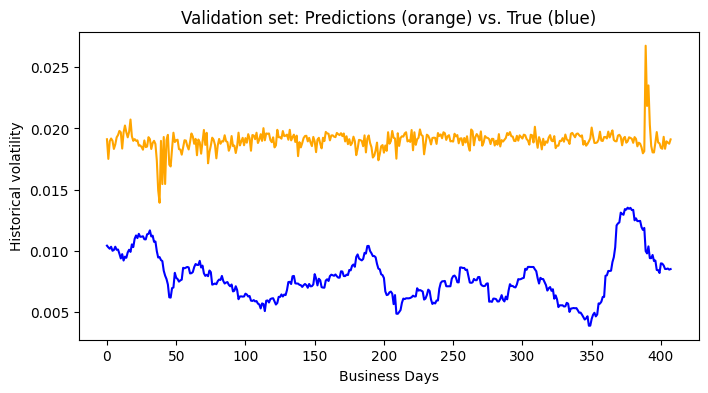

In [14]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Historical volatility')
ax.set_xlabel('Business Days')
ax.plot(x, labels, color='blue')
ax.plot(x, np.asarray(preds), color='orange')
fig.savefig(IMAGE_DIR / 'D-LSTM-full')

The full set of features appears to have introduced too much noise -- the model behaves much less consistently than in the case with limited input.

In [15]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds))}')

R2: -33.91883850097656
MAE: 0.0112040089443326
RMSE: 0.011406457051634789
MSE: 0.00013010726252105087
